# pySPLIT on real Xenium data

**Removing transcript spillover from a 10x Xenium breast cancer sample.**

> ⚠️ **pySPLIT is an unofficial Python implementation of the
> [SPLIT](https://github.com/bdsc-tds/SPLIT) R package.** The method is the work
> of Bilous et al., *Nature Methods* (2026),
> [doi:10.1038/s41592-026-03089-8](https://doi.org/10.1038/s41592-026-03089-8) 

Segmented cells in imaging-based spatial data pick up transcripts belonging to
their neighbours. A T cell sitting inside a tumour looks part-tumour; cluster
that and you get a "hybrid" population that is an artefact of segmentation, not
biology. SPLIT rescales each observed count by the share of expected expression
attributable to the cell's *own* primary cell type:

$$
\text{purified}_{c,g}
  = \text{counts}_{c,g}\cdot
    \frac{w_{c,t_1}\,R_{t_1,g}}{\sum_t w_{c,t}\,R_{t,g}}
$$

where $t_1$ is the cell's primary cell type, $w$ its deconvolution weights and
$R$ a single-cell reference. A gene with no reference support in $t_1$ gets a
zero numerator and is removed outright.

## What this notebook does

1. load the public Xenium sample and its matched Chromium reference
2. deconvolve with [`rctd-py`](https://github.com/p-gueguen/rctd-py) in doublet mode
3. **SPLIT** — purify everything
4. **Spatially-aware SPLIT** — purify only cells with local evidence of contamination
5. **SPLIT-shift** — relabel cells whose expression disagrees with their annotation
6. score all four with marker-gene specificity

### Requirements

```bash
pip install "pysplit-st[all]" rctd-py scanpy openpyxl
```

~200 MB of downloads plus a ~400 MB `rctd-py` cache. Every stage is cached, so
re-running is cheap. Runtime on 18 CPU cores, no GPU: a few minutes.

---
## 0. Setup

Chart styling follows one rule that matters for this dataset: **17 cell types
cannot become 17 colours.** Past roughly seven, colour stops carrying identity
and becomes decoration. So categorical colour is assigned to the seven
higher-level *classes*, and anything scatter-shaped is faceted — one hue per
panel — rather than rainbow-coded.

In [1]:
import sys, warnings
from pathlib import Path

warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
import scanpy as sc

import pysplit

# The heavy lifting (download, deconvolve) lives in the companion script so the
# notebook and the script cannot drift apart.
sys.path.insert(0, str(Path.cwd()))
sys.path.insert(0, str(Path.cwd() / "examples"))
import tutorial_xenium_breast_cancer as tut

pysplit.set_verbosity("WARNING")     # keep the notebook readable
sc.settings.verbosity = 0
print("pySPLIT", pysplit.__version__)

pySPLIT 0.3.0


In [2]:
# ---- palette -------------------------------------------------------------
# A validated 8-slot categorical set, plus chart ink. Only the first seven
# slots are used, one per cell-type class, assigned in fixed alphabetical
# order so a colour always means the same class in every figure.
SURFACE   = "#fcfcfb"
INK       = "#0b0b0b"
INK_2     = "#52514e"
MUTED     = "#898781"
GRID      = "#e1e0d9"
BASELINE  = "#c3c2b7"
CONTEXT   = "#dcdbd4"      # for "all other cells" in faceted maps

SERIES = ["#2a78d6", "#eb6834", "#1baf7a", "#eda100",
          "#e87ba4", "#008300", "#4a3aa7", "#e34948"]
BLUE, ORANGE = SERIES[0], SERIES[1]

# sequential blue ramp, light -> dark, for continuous magnitude
SEQ_BLUE = ["#cde2fb", "#9ec5f4", "#6da7ec", "#3987e5",
            "#2a78d6", "#256abf", "#184f95", "#0d366b"]
BLUE_CMAP = mpl.colors.LinearSegmentedColormap.from_list("seqblue", SEQ_BLUE)

CLASSES = sorted(set(tut.CELL_TYPE_TO_CLASS.values()))
CLASS_COLOR = {cls: SERIES[i] for i, cls in enumerate(CLASSES)}
print(f"{len(tut.CELL_TYPE_TO_CLASS)} cell types -> {len(CLASSES)} classes:")
for cls in CLASSES:
    print(f"  {CLASS_COLOR[cls]}  {cls}")

17 cell types -> 7 classes:
  #2a78d6  B cell
  #eb6834  Endothelial
  #1baf7a  Epithelial
  #eda100  Myeloid
  #e87ba4  Myoepithelial
  #008300  Stromal
  #4a3aa7  T cell


In [3]:
# ---- chart defaults ------------------------------------------------------
mpl.rcParams.update({
    "figure.dpi": 130,
    "savefig.dpi": 130,
    "figure.facecolor": SURFACE,
    "axes.facecolor": SURFACE,
    "font.family": ["DejaVu Sans"],
    "font.size": 9,
    "text.color": INK,
    "axes.labelcolor": INK_2,
    "axes.edgecolor": BASELINE,
    "axes.titlecolor": INK,
    "axes.titlesize": 10,
    "axes.titleweight": "bold",
    "axes.titlelocation": "left",
    "axes.titlepad": 8,
    "xtick.color": MUTED,
    "ytick.color": MUTED,
    "xtick.labelcolor": INK_2,
    "ytick.labelcolor": INK_2,
    "legend.frameon": False,
    "legend.fontsize": 8,
    "axes.grid": False,
})


def style(ax, grid_axis=None):
    """Recessive chrome: no box, hairline solid gridlines on one axis only."""
    for side in ("top", "right", "left", "bottom"):
        ax.spines[side].set_visible(False)
    if grid_axis:
        ax.grid(axis=grid_axis, color=GRID, linewidth=0.6, linestyle="-")
        ax.set_axisbelow(True)
    ax.tick_params(length=0)
    return ax


def bar_labels(ax, bars, values, fmt="{:.3f}", pad=0.004, color=INK):
    """Direct-label bars - values are read off the mark, not a tooltip."""
    for bar, value in zip(bars, values):
        ax.text(bar.get_width() + pad, bar.get_y() + bar.get_height() / 2,
                fmt.format(value), va="center", ha="left", fontsize=8, color=color)


def facet_map(adata, groups, group_colors, coords_key="spatial", ncols=4,
              size=1.0, title=None, context_size=0.5):
    """Small multiples over classes: one hue per panel, greyed context behind.

    Seven classes on one scatter would need seven hues that stay separable
    everywhere they touch - faceting sidesteps that entirely and reads better.
    """
    xy = np.asarray(adata.obsm[coords_key])
    labels = pd.Series(np.asarray(groups), index=adata.obs_names)
    present = [c for c in CLASSES if (labels == c).any()]
    nrows = int(np.ceil(len(present) / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(2.5 * ncols, 2.6 * nrows),
                             squeeze=False)
    for ax in axes.ravel():
        ax.set_visible(False)
    for i, cls in enumerate(present):
        ax = axes[i // ncols][i % ncols]
        ax.set_visible(True)
        mask = (labels == cls).to_numpy()
        ax.scatter(xy[:, 0], -xy[:, 1], s=context_size, c=CONTEXT,
                   linewidths=0, rasterized=True)
        ax.scatter(xy[mask, 0], -xy[mask, 1], s=size, c=group_colors[cls],
                   linewidths=0, rasterized=True)
        ax.set_title(f"{cls}  ({int(mask.sum()):,})", fontsize=9)
        ax.set_xticks([]); ax.set_yticks([])
        ax.set_aspect("equal")
        for side in ax.spines:
            ax.spines[side].set_visible(False)
    if title:
        fig.suptitle(title, x=0.01, y=0.995, ha="left", va="top", fontsize=11,
                     fontweight="bold", color=INK)
        fig.tight_layout(rect=(0, 0, 1, 0.95))
    else:
        fig.tight_layout()
    return fig

---
## 1. The data

> Janesick, A., Shelansky, R., Gottscho, A.D. et al. *High resolution mapping of
> the tumor microenvironment using integrated single-cell, spatial and in situ
> analysis.* **Nature Communications** 14, 8353 (2023).

| | |
|---|---|
| **Spatial** | Xenium FFPE Human Breast Cancer Rep 1 — 167,780 cells × 313 genes |
| **Reference** | Chromium FFPE Human Breast Cancer — 26,031 annotated cells, 17 cell types |

We crop to `x > 6000, y > 4000` so this runs in minutes. Cropping rather than
subsampling is deliberate: SPLIT's spatial mode reasons about physical
neighbourhoods, and random subsampling would tear them apart.

In [4]:
OUTDIR = Path(tut.os.environ.get("PYSPLIT_TUTORIAL_DIR", "pysplit_tutorial"))
OUTDIR.mkdir(parents=True, exist_ok=True)

xenium, reference = tut.load_data(OUTDIR, full_section=False)
print(f"Xenium    {xenium.n_obs:,} cells x {xenium.n_vars} genes")
print(f"Reference {reference.n_obs:,} cells x {reference.n_vars} genes")
reference.obs["cell_type"].value_counts().to_frame("cells")


>>> Loading cached AnnData objects


Xenium    7,804 cells x 313 genes
Reference 26,031 cells x 18082 genes


,cells
cell_type,
Invasive_Tumor,4559
Macrophages_1,2964
CD4+_T_Cells,2899
Stromal,2609
DCIS 2,2159
DCIS 1,1862
CD8+_T_Cells,1843
B_Cells,1463
Prolif_Invasive_Tumor,1329


### A reference worth deconvolving against

The study's own `Hybrid` calls are dropped. That is not cosmetic: a reference
containing doublets teaches the deconvolution that mixed profiles are legitimate
cell types — exactly the signal SPLIT exists to remove.

Cell types are also mapped to seven broader **classes**. Passing these to RCTD
is strongly recommended — it stops the model agonising over distinctions a
313-gene panel cannot resolve, which makes it more robust and sharply reduces
rejected cells. It also unlocks the class-level neighbourhood metrics that
SPLIT-shift needs.

In [5]:
pd.Series(tut.CELL_TYPE_TO_CLASS, name="class").rename_axis("cell_type").to_frame()

,class
cell_type,
B_Cells,B cell
CD4+_T_Cells,T cell
CD8+_T_Cells,T cell
IRF7+_DCs,Myeloid
LAMP3+_DCs,Myeloid
Macrophages_1,Myeloid
Macrophages_2,Myeloid
Mast_Cells,Myeloid
DCIS 1,Epithelial


---
## 2. Deconvolution (RCTD, doublet mode)

**Doublet mode is required.** SPLIT's premise is a primary *and* a secondary cell
type per cell; full mode gives no such decomposition.

Two `rctd-py` gotchas, both handled by the helper:

- **`compile=True` is its default and a trap on CPU.** It hands the solver to
  `torch.compile`, which pays off on a GPU but costs many minutes of one-time
  compilation on CPU — long enough to look like a hang. Disabled when no GPU is
  present, this step takes ~40 s.
- **`class_df` must be a plain dict**, not a DataFrame (unlike the R package),
  or it fails claiming *every* cell type is unmapped.

`from_rctd_py` also runs `run_post_process_rctd`, which is **not optional**: RCTD
reports a `second_type` even for cells where one type holds essentially all the
weight, and that label is arbitrary. Post-processing relabels those as confident
singlets with no secondary type, so purification leaves them alone instead of
stripping a real phenotype.

In [6]:
rctd_result = tut.deconvolve(xenium, reference, OUTDIR)
results = rctd_result.results_df
results[["spot_class", "first_type", "second_type",
         "weight_first_type", "weight_second_type"]].head()


>>> Loading cached RCTD result



>>> Post-processing the deconvolution for SPLIT


  spot class distribution (%):
spot_class
singlet              81.1
doublet_certain      15.8
doublet_uncertain     2.2
reject                1.0


,spot_class,first_type,second_type,weight_first_type,weight_second_type
cell_id,,,,,
11672,singlet,DCIS 1,Prolif_Invasive_Tumor,0.723350,0.276650
11673,singlet,DCIS 1,Myoepi_ACTA2+,0.771241,0.228759
11674,singlet,DCIS 1,Prolif_Invasive_Tumor,0.606286,0.393714
11675,singlet,DCIS 1,Invasive_Tumor,0.644716,0.355284
11676,singlet,DCIS 1,Myoepi_ACTA2+,0.865103,0.134897


### How confident was the deconvolution?

One measure across four ordered categories, so this is a magnitude comparison —
a single hue, not four. `singlet` dominates; `reject` cells are the ones SPLIT
will discard as having no trustworthy annotation.

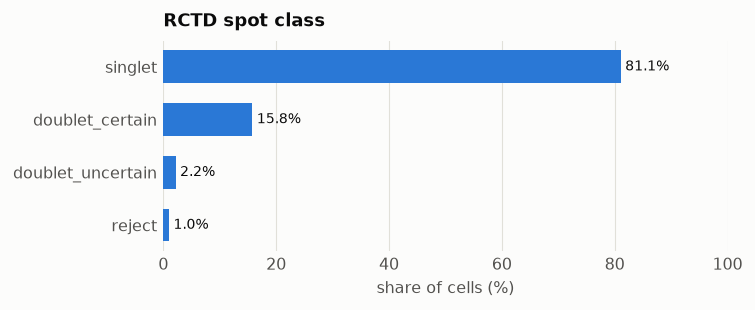

,cells,share_%
spot_class,,
singlet,6325,81.1
doublet_certain,1231,15.8
doublet_uncertain,169,2.2
reject,78,1.0


In [7]:
order = ["singlet", "doublet_certain", "doublet_uncertain", "reject"]
counts = results["spot_class"].astype(object).value_counts().reindex(order).fillna(0)
share = 100 * counts / counts.sum()

fig, ax = plt.subplots(figsize=(5.6, 2.1))
bars = ax.barh(range(len(order)), share.to_numpy(), height=0.62,
               color=BLUE, linewidth=0)
bar_labels(ax, bars, share.to_numpy(), fmt="{:.1f}%", pad=0.8)
ax.set_yticks(range(len(order)), order)
ax.invert_yaxis()
ax.set_xlim(0, 100)
ax.set_xlabel("share of cells (%)")
ax.set_title("RCTD spot class")
style(ax, grid_axis="x")
plt.show()

pd.DataFrame({"cells": counts.astype(int), "share_%": share.round(1)})

### Where the cell types are

Faceted by class rather than coloured by 17 types — each panel shows one class
against the full section in grey, so the tissue architecture stays legible.
Note the tumour mass and the immune cells threaded through it: those interfaces
are precisely where spillover happens.

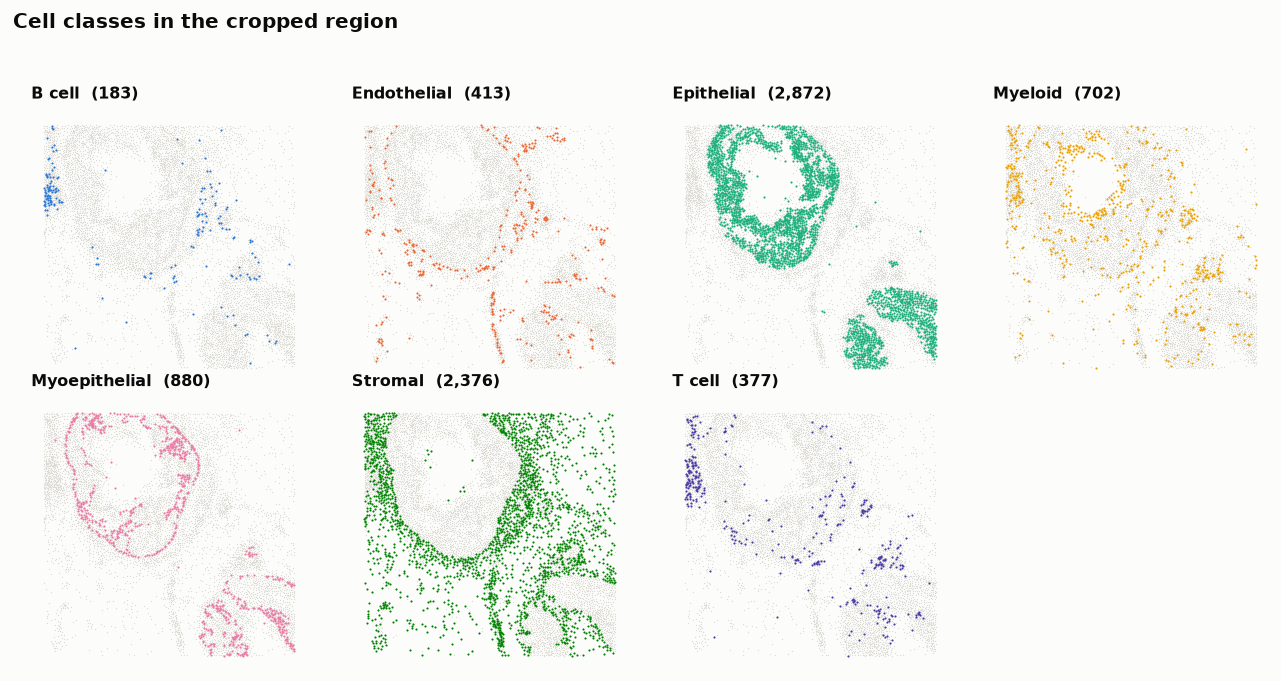

In [8]:
xenium_annotated = xenium[[c for c in xenium.obs_names if c in results.index]].copy()
xenium_annotated.obs["first_type"] = results.loc[
    xenium_annotated.obs_names, "first_type"].to_numpy()
xenium_annotated.obs["class"] = (
    xenium_annotated.obs["first_type"].map(tut.CELL_TYPE_TO_CLASS))

facet_map(xenium_annotated, xenium_annotated.obs["class"], CLASS_COLOR,
          size=1.4, title="Cell classes in the cropped region")
plt.show()

---
## 3. SPLIT

`remove_residual_contamination=True` additionally zeroes genes with no
*specific* reference support in the cell's own type — background that
proportional redistribution cannot touch. The threshold is derived from the
reference, so there is nothing to tune.

Two things to know about the output: purified counts are **fractional**, and
`reject` cells are **dropped**.

In [9]:
purified = pysplit.purify(xenium, rctd=rctd_result,
                          remove_residual_contamination=True, verbose=False)

kept = 100 * float(purified.X.sum()) / float(xenium[purified.obs_names].X.sum())
print(f"{purified.n_obs:,} cells retained ({xenium.n_obs - purified.n_obs} dropped)")
print(f"{kept:.1f}% of counts kept")
print(f"auto belonging_threshold = {purified.uns['pysplit']['belonging_threshold']:.4f}")
purified

79 cell(s) have no deconvolution result and are dropped from the output.


6 gene(s) are absent from the reference and are dropped from the output.


Some deconvolution weights do not sum to 1.


7,725 cells retained (79 dropped)
68.5% of counts kept
auto belonging_threshold = 0.0514


AnnData object with n_obs × n_vars = 7725 × 307
    obs: 'cell_id', 'primary_cell_type', 'first_type', 'w1_primary', 'n_cell_types', 'purification_status', 'nCount_raw', 'nCount_purified', 'spot_class', 'second_type', 'min_score', 'singlet_score', 'n_candidates', 'max_doublet_weight', 'rctd_weights_entropy', 'weight_first_type', 'weight_second_type', 'first_type_class', 'second_type_class', 'same_class', 'x', 'y', 'annot_max_weight', 'annot_min_singlet_score', 'annot_max_doublet_weight', 'w1_larger_w2'
    var: 'gene_ids', 'feature_types'
    uns: 'pysplit'
    obsm: 'spatial'
    layers: 'counts_raw'

### Which cell types lose the most?

The share of counts SPLIT removes per cell type is itself informative. The
biggest losses land on the **rare** populations — mast cells, the two dendritic
subsets, T cells — which are exactly the cells most likely to be sitting inside
a dominant neighbour and least likely to dominate their own neighbourhood. The
abundant stromal and epithelial populations change least.

Note that `Prolif_Invasive_Tumor` is near the top too, so this is not a clean
"immune loses, tumour keeps" story: it is a rare population (1,329 reference
cells) that is transcriptionally close to the far more abundant `Invasive_Tumor`,
and proximity in the reference is enough to make the deconvolution split weight
between them.

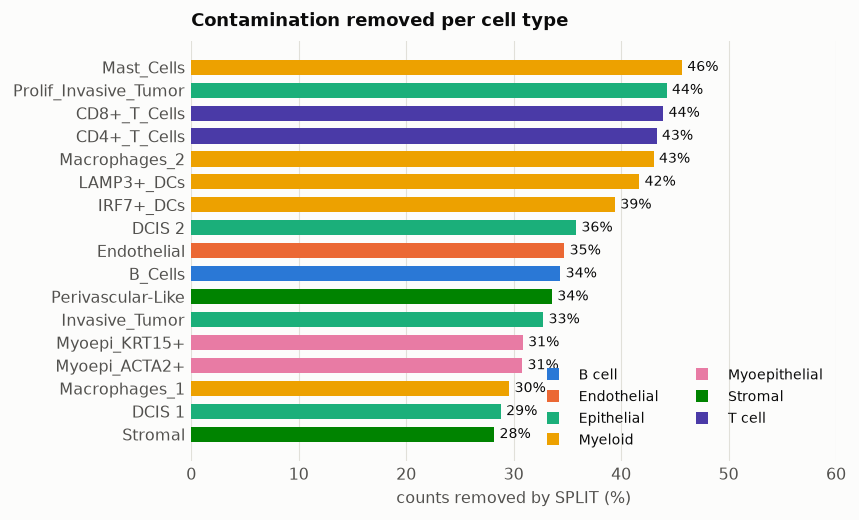

,raw,purified,cells,removed_%
cell_type,,,,
Stromal,511627.0,367391.5,2169,28.2
DCIS 1,659211.0,469306.7,2455,28.8
Macrophages_1,91349.0,64317.4,503,29.6
Myoepi_ACTA2+,88822.0,61470.4,506,30.8
Myoepi_KRT15+,82617.0,57128.5,368,30.9
Invasive_Tumor,4509.0,3032.3,28,32.8
Perivascular-Like,24807.0,16479.9,205,33.6
B_Cells,22884.0,15025.0,169,34.3
Endothelial,71912.0,46947.6,408,34.7


In [10]:
raw_aligned = xenium[purified.obs_names, purified.var_names]
raw_per_cell = np.asarray(raw_aligned.X.sum(axis=1)).ravel()
pure_per_cell = np.asarray(purified.X.sum(axis=1)).ravel()

per_type = pd.DataFrame({
    "cell_type": purified.obs["first_type"].to_numpy(),
    "raw": raw_per_cell,
    "purified": pure_per_cell,
}).groupby("cell_type", observed=True).agg(
    raw=("raw", "sum"), purified=("purified", "sum"), cells=("raw", "size"))
per_type["removed_%"] = 100 * (1 - per_type["purified"] / per_type["raw"])
per_type = per_type.sort_values("removed_%")

fig, ax = plt.subplots(figsize=(6.4, 4.2))
colors = [CLASS_COLOR[tut.CELL_TYPE_TO_CLASS[t]] for t in per_type.index]
bars = ax.barh(range(len(per_type)), per_type["removed_%"].to_numpy(),
               height=0.66, color=colors, linewidth=0)
bar_labels(ax, bars, per_type["removed_%"].to_numpy(), fmt="{:.0f}%", pad=0.5)
ax.set_yticks(range(len(per_type)), per_type.index)
ax.set_xlabel("counts removed by SPLIT (%)")
ax.set_title("Contamination removed per cell type")
ax.set_xlim(0, max(60, per_type["removed_%"].max() * 1.15))
style(ax, grid_axis="x")
handles = [plt.Line2D([], [], marker="s", linestyle="", markersize=7,
                      markerfacecolor=CLASS_COLOR[c], markeredgecolor="none", label=c)
           for c in CLASSES]
ax.legend(handles=handles, loc="lower right", ncol=2, fontsize=8)
plt.show()

per_type.round(1)

---
## 4. Spatially-aware SPLIT

Purifying every cell over-corrects. A cell whose secondary signal is *not*
present in its physical surroundings more likely holds a genuine phenotype —
possibly one absent from the reference — than contamination.

`neighborhood_weights_second_type` is the **local diffusion score**: the share of
a cell's spatial neighbourhood made up of its own secondary cell type. High means
the secondary signal really is next door.

The `radius=15` µm pruning is what keeps the graph to physically adjacent cells;
without it the 20 nearest neighbours reach across empty tissue and the score
stops meaning anything.

In [11]:
work = xenium[purified.obs_names].copy()
work.obs = work.obs.join(results, rsuffix="_rctd")

spatial_nw = pysplit.build_spatial_network(
    work, basis="spatial", k_knn=20, prune=True, radius=15)
pysplit.spatial_metrics(spatial_nw, rctd_result)
work.obs = work.obs.join(spatial_nw.to_dataframe())

score = work.obs["neighborhood_weights_second_type"]
print(f"median {score.median():.3f} | {100 * (score > 0.05).mean():.0f}% above 0.05")

median 0.081 | 54% above 0.05


### The score is a property of the surroundings, not of annotation confidence

Ordering by spot class is the expected one — cells the deconvolution was least
sure about sit in the most mixed neighbourhoods — but note how **small** the gap
between `singlet` and `doublet_certain` is. That is the point: a *confident*
singlet in the middle of a tumour still scores high, and that is exactly the
case spatially-aware SPLIT exists to catch. Do not expect this score to separate
spot classes cleanly.

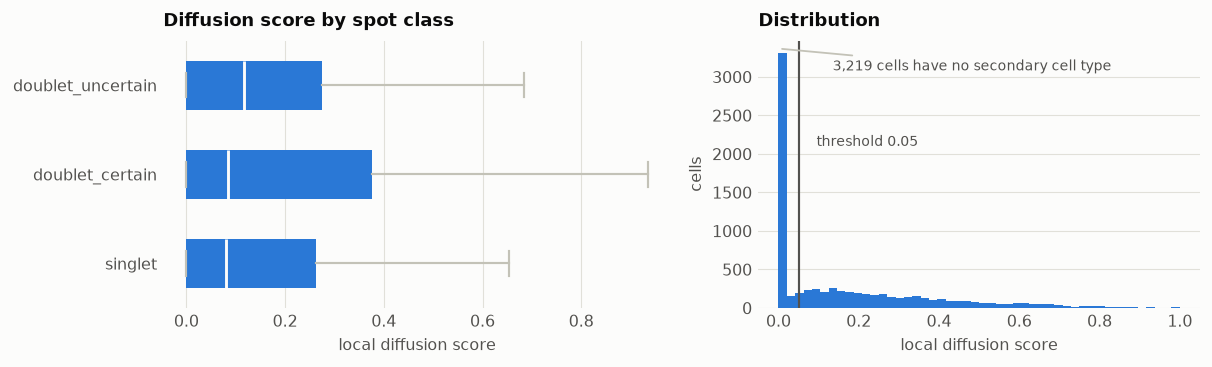

,count,25%,50%,75%
spot_class,,,,
doublet_uncertain,169.0,0.0,0.117,0.275
doublet_certain,1231.0,0.0,0.085,0.376
singlet,6325.0,0.0,0.080,0.262


In [12]:
groups = [g for g in ["singlet", "doublet_certain", "doublet_uncertain"]
          if (work.obs["spot_class"].astype(object) == g).any()]
data = [work.obs.loc[work.obs["spot_class"].astype(object) == g,
                     "neighborhood_weights_second_type"].dropna().to_numpy()
        for g in groups]

fig, axes = plt.subplots(1, 2, figsize=(9.4, 2.9),
                         gridspec_kw={"width_ratios": [1.15, 1]})

ax = axes[0]
box = ax.boxplot(data, vert=False, widths=0.55, patch_artist=True,
                 showfliers=False, medianprops={"color": SURFACE, "linewidth": 1.6},
                 whiskerprops={"color": BASELINE, "linewidth": 1.2},
                 capprops={"color": BASELINE, "linewidth": 1.2})
for patch in box["boxes"]:
    patch.set(facecolor=BLUE, edgecolor="none")
# No median labels inside the plot: they collided with the box edge, and the
# describe() table below already reports them.
ax.set_yticks(range(1, len(groups) + 1), groups)
ax.set_xlabel("local diffusion score")
ax.set_title("Diffusion score by spot class")
style(ax, grid_axis="x")

ax = axes[1]
ax.hist(score.dropna().to_numpy(), bins=48, color=BLUE, linewidth=0)
ax.axvline(0.05, color=INK_2, linewidth=1.2)
top = ax.get_ylim()[1]
ax.annotate("threshold 0.05", xy=(0.05, top * 0.62), xytext=(10, 0),
            textcoords="offset points", fontsize=8, color=INK_2, va="center")
# The spike at exactly zero is not a tail - it is every cell with no secondary
# cell type at all, for which the score is 0 by definition.
n_zero = int((score.fillna(0) == 0).sum())
ax.annotate(f"{n_zero:,} cells have no secondary cell type",
            xy=(0.0, top * 0.97), xytext=(30, -6), textcoords="offset points",
            fontsize=8, color=INK_2, va="top",
            arrowprops=dict(arrowstyle="-", color=BASELINE, linewidth=1))
ax.set_xlabel("local diffusion score")
ax.set_ylabel("cells")
ax.set_title("Distribution")
style(ax, grid_axis="y")
fig.tight_layout()
plt.show()

work.obs.groupby("spot_class", observed=True)[
    "neighborhood_weights_second_type"].describe()[["count", "25%", "50%", "75%"]].round(3)

### The score in space

Continuous magnitude, so a single-hue sequential ramp — light means near zero.
The high-scoring cells cluster at the boundaries between tissue compartments,
which is what a spillover score should do.

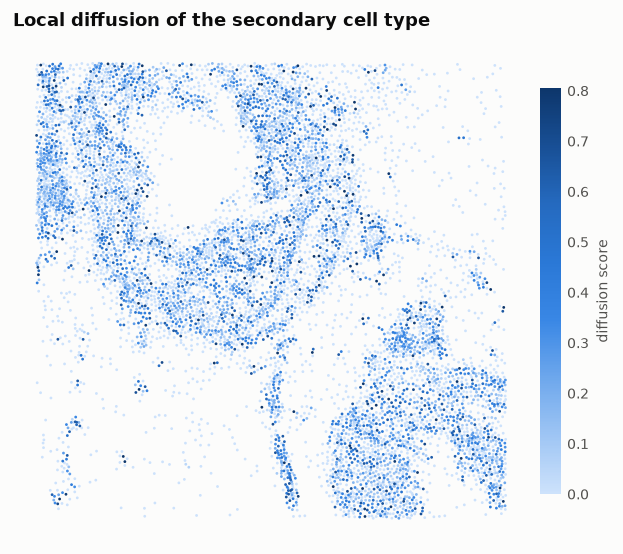

In [13]:
xy = np.asarray(work.obsm["spatial"])
values = score.fillna(0).to_numpy()

fig, ax = plt.subplots(figsize=(5.6, 5.0))
order_idx = np.argsort(values)          # draw high scores last so they stay visible
sc_art = ax.scatter(xy[order_idx, 0], -xy[order_idx, 1], c=values[order_idx],
                    cmap=BLUE_CMAP, s=2.4, linewidths=0,
                    vmin=0, vmax=np.quantile(values, 0.99), rasterized=True)
ax.set_aspect("equal"); ax.set_xticks([]); ax.set_yticks([])
for side in ax.spines:
    ax.spines[side].set_visible(False)
ax.set_title("Local diffusion of the secondary cell type")
cbar = fig.colorbar(sc_art, ax=ax, fraction=0.036, pad=0.02)
cbar.set_label("diffusion score", color=INK_2, fontsize=8)
cbar.outline.set_visible(False)
cbar.ax.tick_params(length=0, labelsize=8, labelcolor=INK_2)
plt.show()

In [14]:
spatially_aware = pysplit.balance_by_score(
    work, purified, threshold=0.05,
    score_name="neighborhood_weights_second_type")

status = spatially_aware.obs["purification_status"].value_counts()
print(status.to_string())
print(f"\n{100 * status.get('purified', 0) / spatially_aware.n_obs:.0f}% purified, "
      "the rest kept raw")

purification_status
purified    4254
raw         3471

55% purified, the rest kept raw


---
## 5. SPLIT-shift

When contamination is strong enough, the deconvolution assigns the cell to the
*contaminating* type. SPLIT-shift swaps the primary and secondary labels for
cells whose transcriptomic neighbourhood agrees with neither their primary type
nor its class, while matching their secondary class — and takes the **residual**
as such a cell's profile.

`k_knn=100` is deliberately large: the question is what phenotype a broad
expression neighbourhood agrees on, which needs a stable majority.

In [15]:
tmp = work.copy()
sc.pp.normalize_total(tmp); sc.pp.log1p(tmp); sc.pp.pca(tmp, n_comps=50)
work.obsm["X_pca"] = tmp.obsm["X_pca"]

transcriptomic_nw = pysplit.build_transcriptomics_network(
    work, basis="X_pca", dims=range(50), k_knn=100)
pysplit.transcriptomics_metrics(transcriptomic_nw, rctd_result)
work.obs = work.obs.join(transcriptomic_nw.to_dataframe(), rsuffix="_tr")

agreement = work.obs["first_type_neighborhood_agreement"]
print(f"{100 * (agreement == False).mean():.0f}% of cells disagree with their "
      "transcriptomic neighbourhood")

shifted = pysplit.balance_by_score(
    work, purified, threshold=0.05,
    score_name="neighborhood_weights_second_type", swap_labels=True)
n_swapped = int(shifted.obs["swap"].sum())
print(f"{n_swapped:,} cell(s) relabelled")

15% of cells disagree with their transcriptomic neighbourhood


487 cell(s) relabelled


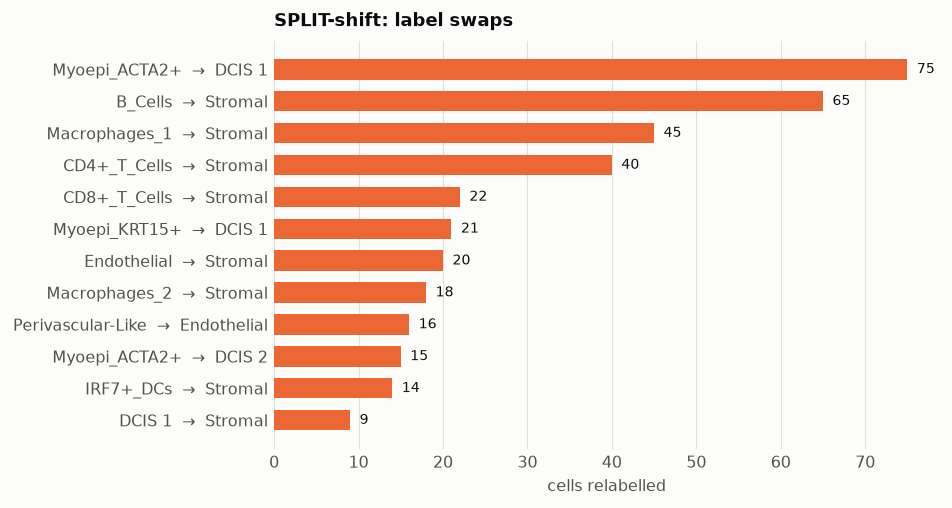

,,cells
first_type_before_swap,first_type,
Myoepi_ACTA2+,DCIS 1,75
B_Cells,Stromal,65
Macrophages_1,Stromal,45
CD4+_T_Cells,Stromal,40
CD8+_T_Cells,Stromal,22
Myoepi_KRT15+,DCIS 1,21
Endothelial,Stromal,20
Macrophages_2,Stromal,18
Perivascular-Like,Endothelial,16


In [16]:
if n_swapped:
    swapped = shifted.obs.loc[shifted.obs["swap"].to_numpy(dtype=bool)]
    flow = (swapped.groupby(["first_type_before_swap", "first_type"], observed=True)
            .size().sort_values(ascending=False).head(12))
    labels = [f"{a}  →  {b}" for a, b in flow.index]

    fig, ax = plt.subplots(figsize=(6.6, max(2.0, 0.34 * len(flow))))
    bars = ax.barh(range(len(flow)), flow.to_numpy(), height=0.64,
                   color=ORANGE, linewidth=0)
    bar_labels(ax, bars, flow.to_numpy(), fmt="{:.0f}", pad=max(flow) * 0.015)
    ax.set_yticks(range(len(flow)), labels)
    ax.invert_yaxis()
    ax.set_xlabel("cells relabelled")
    ax.set_title("SPLIT-shift: label swaps")
    style(ax, grid_axis="x")
    plt.show()
    display(flow.to_frame("cells"))
else:
    print("No cells met the SPLIT-shift criterion.")

---
## 6. Did it work?

Marker-gene specificity, scored on genes SPLIT never sees. For each cell: what
share of its counts fall on its **own** lineage's markers, versus on **foreign**
lineage markers? Foreign-marker signal inside a cell is what contamination looks
like, so the two should move in opposite directions.

Two series here, so two hues plus a legend, and every bar is directly labelled —
the numbers are readable off the chart, not just from a hover.

In [17]:
variants = {
    "Raw": (work, "first_type"),
    "SPLIT": (purified, "first_type"),
    "Spatially-aware": (spatially_aware, "first_type"),
    "SPLIT-shift": (shifted, "first_type"),
}
rows = []
for name, (adata, column) in variants.items():
    own, foreign = tut.marker_specificity(adata, column)
    rows.append({"variant": name, "own": own, "foreign": foreign,
                 "ratio": own / foreign})
table = pd.DataFrame(rows).set_index("variant")
table.round(4)

,own,foreign,ratio
variant,,,
Raw,0.1518,0.0973,1.5602
SPLIT,0.1879,0.0685,2.7428
Spatially-aware,0.1728,0.0791,2.1841
SPLIT-shift,0.1765,0.0788,2.2403


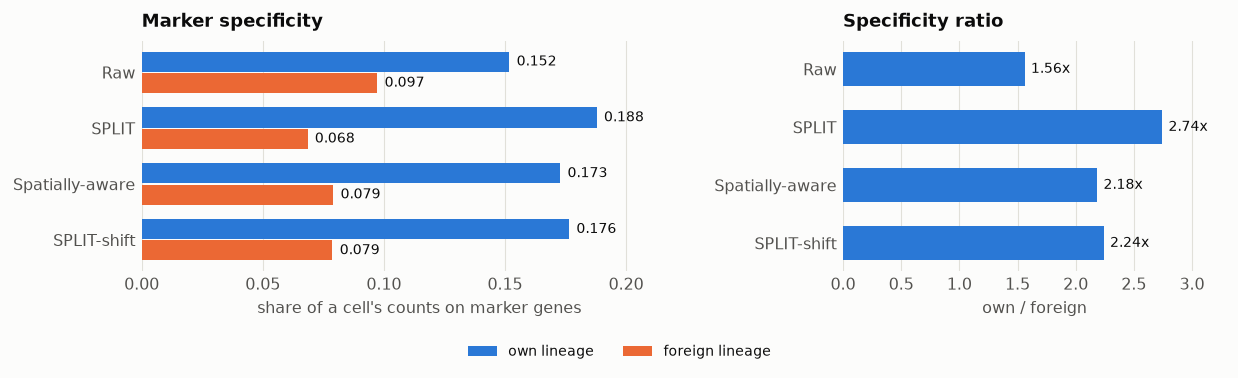

In [18]:
y = np.arange(len(table))
height = 0.36
gap = 0.02                       # a small surface gap keeps adjacent fills apart

fig, axes = plt.subplots(1, 2, figsize=(9.6, 2.9),
                         gridspec_kw={"width_ratios": [1.45, 1]})

ax = axes[0]
b1 = ax.barh(y - height / 2 - gap / 2, table["own"], height=height,
             color=BLUE, linewidth=0, label="own lineage")
b2 = ax.barh(y + height / 2 + gap / 2, table["foreign"], height=height,
             color=ORANGE, linewidth=0, label="foreign lineage")
bar_labels(ax, b1, table["own"].to_numpy(), pad=0.003)
bar_labels(ax, b2, table["foreign"].to_numpy(), pad=0.003)
ax.set_yticks(y, table.index)
ax.invert_yaxis()
ax.set_xlim(0, table[["own", "foreign"]].to_numpy().max() * 1.22)
ax.set_xlabel("share of a cell's counts on marker genes")
ax.set_title("Marker specificity")
# The legend goes on the figure, not the axes: inside the axes it covered the
# bottom bar's value label, above them it hit the title, and just below them it
# landed on the x-axis label. Space is reserved for it in tight_layout below.
style(ax, grid_axis="x")

ax = axes[1]
bars = ax.barh(y, table["ratio"], height=0.6, color=BLUE, linewidth=0)
bar_labels(ax, bars, table["ratio"].to_numpy(), fmt="{:.2f}x",
           pad=table["ratio"].max() * 0.02)
ax.set_yticks(y, table.index)
ax.invert_yaxis()
ax.set_xlim(0, table["ratio"].max() * 1.2)
ax.set_xlabel("own / foreign")
ax.set_title("Specificity ratio")
style(ax, grid_axis="x")

fig.tight_layout(rect=(0, 0.10, 1, 1))
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="lower center", ncol=2, frameon=False,
           bbox_to_anchor=(0.5, 0.0))
plt.show()

**Full SPLIT wins on this metric** — but read that carefully.

Spatially-aware SPLIT lands *between* raw and full SPLIT, as it must: it only
purified a subset of cells and left the rest untouched. A lower `threshold` moves
it towards full SPLIT.

**Higher marker specificity is not automatically better.** A run that purified
everything down to nothing would score perfectly. Which mode you want is a
judgement call: full SPLIT maximises specificity, spatially-aware SPLIT protects
phenotypes the reference may not contain. The metric informs that choice; it
does not make it.

### The same result, in space and expression

First, cells whose counts SPLIT changed most. Then the UMAP for **all four
variants**, faceted by class, so the visual comparison covers the same ground
as the specificity table above. Purification tightens each class — the "hybrid"
bridges between compartments thin out.

⚠️ **Read the UMAP with care — it is partly circular.** SPLIT rescales each
cell's profile towards its assigned cell type's reference, so tighter, better
separated clusters are to some extent guaranteed by construction rather than
discovered. The same caution applies, more weakly, to the marker-specificity
numbers above: the reference that SPLIT uses also encodes which genes are
lineage markers, so neither measure is fully independent of the method.

For an *independent* check, `examples/simulate_and_validate.py` runs the same
pipeline on simulated spillover with known ground truth, where purification can
be scored against the true profiles. It recovers marker purity from 0.75 to 0.91
and leaves uncontaminated cells untouched. Multiple islands per class below are
expected — a class groups several cell types (Stromal + Perivascular-Like,
Myoepi_ACTA2+ + Myoepi_KRT15+).

**Full SPLIT will look the cleanest, and that is not the same as being the most
correct.** It is the most aggressive of the three: it purifies every cell, and
with `remove_residual_contamination=True` it also hard-zeroes any gene outside
the assigned cell type's reference support. Spatially-aware SPLIT deliberately
leaves the majority of cells raw, so it *should* land between raw and full
SPLIT — and a cell with a genuine phenotype absent from the reference is far
likelier to survive it. Note also that the two knobs are independent: the
spatially-aware variant here selects *which* cells to replace from the same
aggressively purified object, so for the cells it does touch the correction is
just as strong. To soften the per-cell correction as well, purify a second time
with `remove_residual_contamination=False` and balance against that instead.

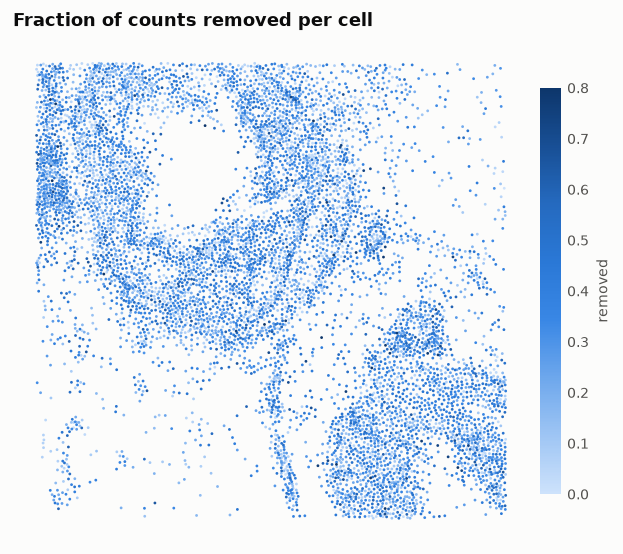

In [19]:
removed_frac = 1 - np.divide(pure_per_cell, raw_per_cell,
                             out=np.zeros_like(pure_per_cell),
                             where=raw_per_cell > 0)

fig, ax = plt.subplots(figsize=(5.6, 5.0))
order_idx = np.argsort(removed_frac)
art = ax.scatter(xy[order_idx, 0], -xy[order_idx, 1],
                 c=removed_frac[order_idx], cmap=BLUE_CMAP, s=2.4,
                 linewidths=0, vmin=0, vmax=0.8, rasterized=True)
ax.set_aspect("equal"); ax.set_xticks([]); ax.set_yticks([])
for side in ax.spines:
    ax.spines[side].set_visible(False)
ax.set_title("Fraction of counts removed per cell")
cbar = fig.colorbar(art, ax=ax, fraction=0.036, pad=0.02)
cbar.set_label("removed", color=INK_2, fontsize=8)
cbar.outline.set_visible(False)
cbar.ax.tick_params(length=0, labelsize=8, labelcolor=INK_2)
plt.show()

In [20]:
def umap_of(adata, label_series):
    obj = adata.copy()
    obj.X = obj.X.astype(np.float32)
    sc.pp.normalize_total(obj); sc.pp.log1p(obj)
    sc.pp.pca(obj, n_comps=30); sc.pp.neighbors(obj, n_neighbors=15)
    sc.tl.umap(obj)
    obj.obs["class"] = pd.Series(label_series, index=obj.obs_names).map(
        tut.CELL_TYPE_TO_CLASS).to_numpy()
    return obj

# All four variants, so the visual comparison covers the same ground as the
# marker-specificity table. Note that `shifted` is coloured by its *post-swap*
# labels - that is the point of SPLIT-shift.
embeddings = {name: umap_of(obj, obj.obs[col])
              for name, (obj, col) in variants.items()}
print("UMAPs computed for:", ", ".join(embeddings))

UMAPs computed for: Raw, SPLIT, Spatially-aware, SPLIT-shift


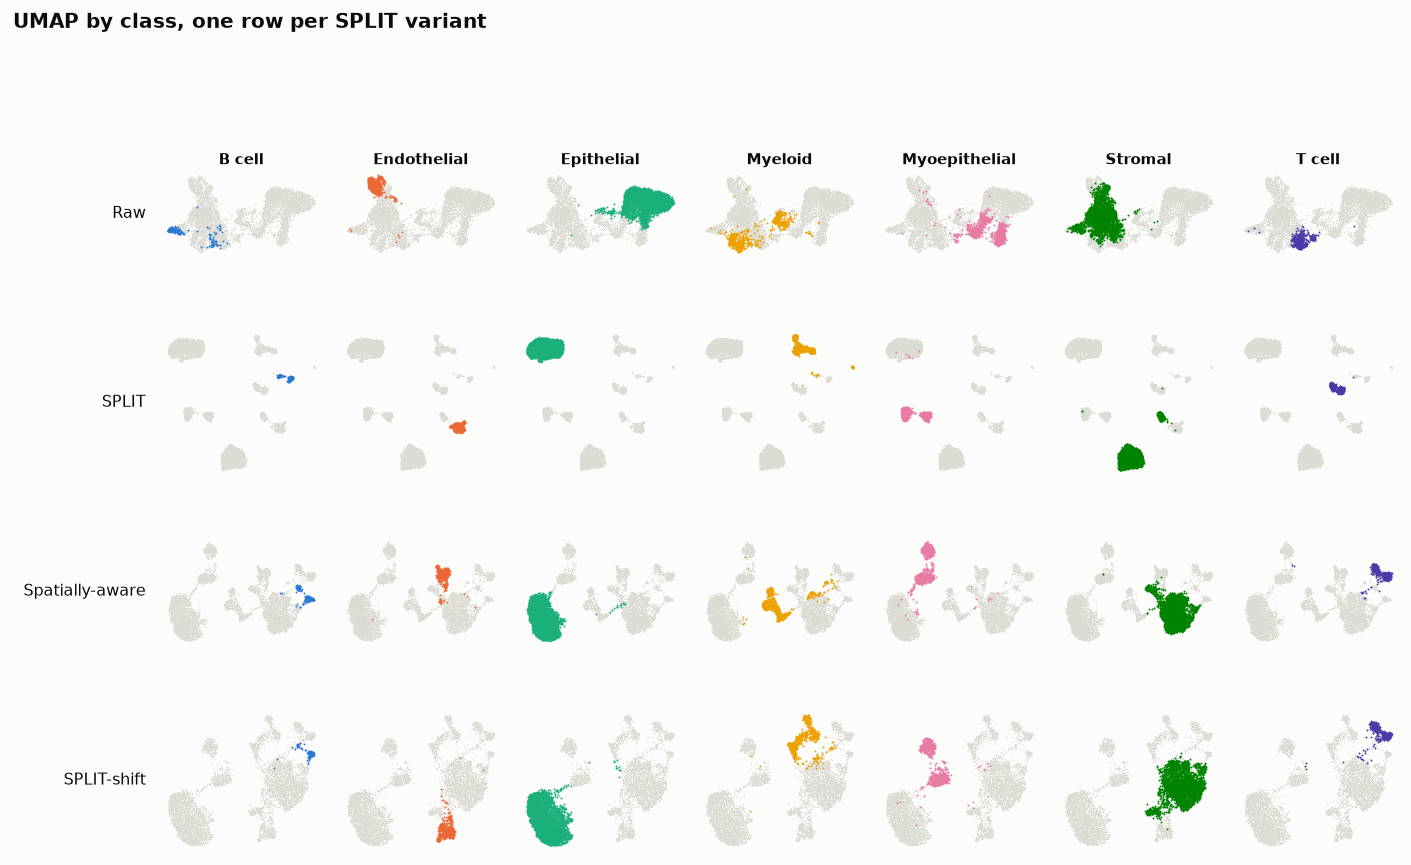

In [21]:
# One row per variant, one column per class. Rows use different embeddings
# (each variant is re-embedded from its own counts), so read down a column to
# see how a class behaves under each correction.
rows, cols = list(embeddings), CLASSES
fig, axes = plt.subplots(len(rows), len(cols),
                         figsize=(1.55 * len(cols), 1.72 * len(rows)),
                         squeeze=False)
for r, name in enumerate(rows):
    obj = embeddings[name]
    xy = obj.obsm["X_umap"]
    labels = obj.obs["class"].to_numpy()
    for c, cls in enumerate(cols):
        ax = axes[r][c]
        mask = labels == cls
        ax.scatter(xy[:, 0], xy[:, 1], s=0.45, c=CONTEXT, linewidths=0,
                   rasterized=True)
        if mask.any():
            ax.scatter(xy[mask, 0], xy[mask, 1], s=1.1, c=CLASS_COLOR[cls],
                       linewidths=0, rasterized=True)
        ax.set_xticks([]); ax.set_yticks([]); ax.set_aspect("equal")
        for side in ax.spines:
            ax.spines[side].set_visible(False)
        if r == 0:
            ax.set_title(cls, fontsize=8.5, loc="center", pad=4)
        if c == 0:
            ax.set_ylabel(name, fontsize=9, rotation=0, ha="right", va="center",
                          labelpad=8, color=INK)
fig.suptitle("UMAP by class, one row per SPLIT variant", x=0.005, y=0.998,
             ha="left", va="top", fontsize=11, fontweight="bold", color=INK)
fig.tight_layout(rect=(0, 0, 1, 0.955))
plt.show()

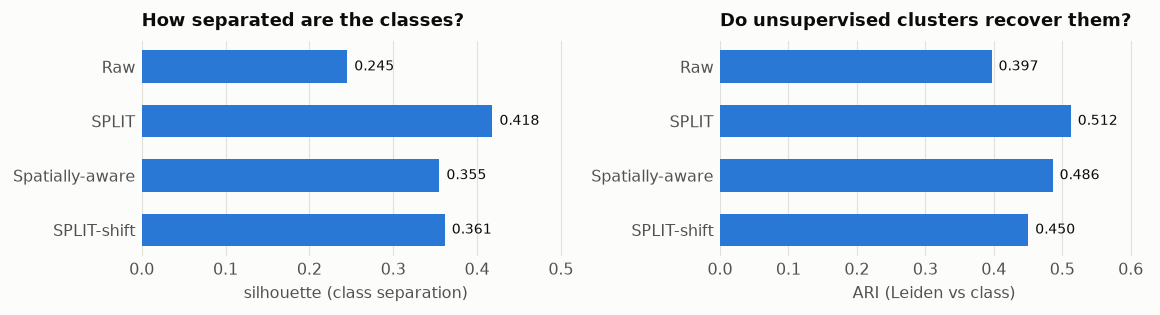

,silhouette,ARI
variant,,
Raw,0.245,0.397
SPLIT,0.418,0.512
Spatially-aware,0.355,0.486
SPLIT-shift,0.361,0.450


In [22]:
# 28 panels are hard to compare by eye, so measure the thing they are meant to
# show: how well does each variant separate the classes it was told about?
#   silhouette - global separation of the labelled groups in PCA space
#   ARI        - agreement between unsupervised Leiden clusters and the labels
from sklearn.metrics import adjusted_rand_score, silhouette_score

rows = []
for name, obj in embeddings.items():
    lab = obj.obs["class"].to_numpy().astype(str)
    keep = obj.obs["class"].notna().to_numpy()
    sc.tl.leiden(obj, key_added="leiden", flavor="igraph", n_iterations=2,
                 directed=False, resolution=1.0)
    rows.append({
        "variant": name,
        "silhouette": silhouette_score(obj.obsm["X_pca"][keep], lab[keep]),
        "ARI": adjusted_rand_score(lab[keep], obj.obs["leiden"].to_numpy()[keep]),
    })
cleanliness = pd.DataFrame(rows).set_index("variant")

y = np.arange(len(cleanliness))
height = 0.36
fig, axes = plt.subplots(1, 2, figsize=(9.0, 2.5))
for ax, col, label in zip(axes, ["silhouette", "ARI"],
                          ["silhouette (class separation)",
                           "ARI (Leiden vs class)"]):
    bars = ax.barh(y, cleanliness[col], height=0.6, color=BLUE, linewidth=0)
    bar_labels(ax, bars, cleanliness[col].to_numpy(), fmt="{:.3f}",
               pad=cleanliness[col].max() * 0.02)
    ax.set_yticks(y, cleanliness.index)
    ax.invert_yaxis()
    ax.set_xlim(0, cleanliness[col].max() * 1.22)
    ax.set_xlabel(label)
    style(ax, grid_axis="x")
axes[0].set_title("How separated are the classes?")
axes[1].set_title("Do unsupervised clusters recover them?")
fig.tight_layout()
plt.show()

cleanliness.round(3)

---
## 7. Bonus: seeing one cell's contamination

Each cell drawn as a pie at its spatial position: slice areas are the
primary/secondary weights, the pie edge marks the primary cell type, and the
centre marker encodes the spot class (coloured dot = `doublet_certain`, black
dot = `doublet_uncertain`, cross = `reject`, nothing = confident `singlet`).

Pies are coloured **by class**, not by cell type, for the same reason as
everywhere else. Below: a T cell with strong local tumour diffusion, plus its
neighbours within 50 µm.

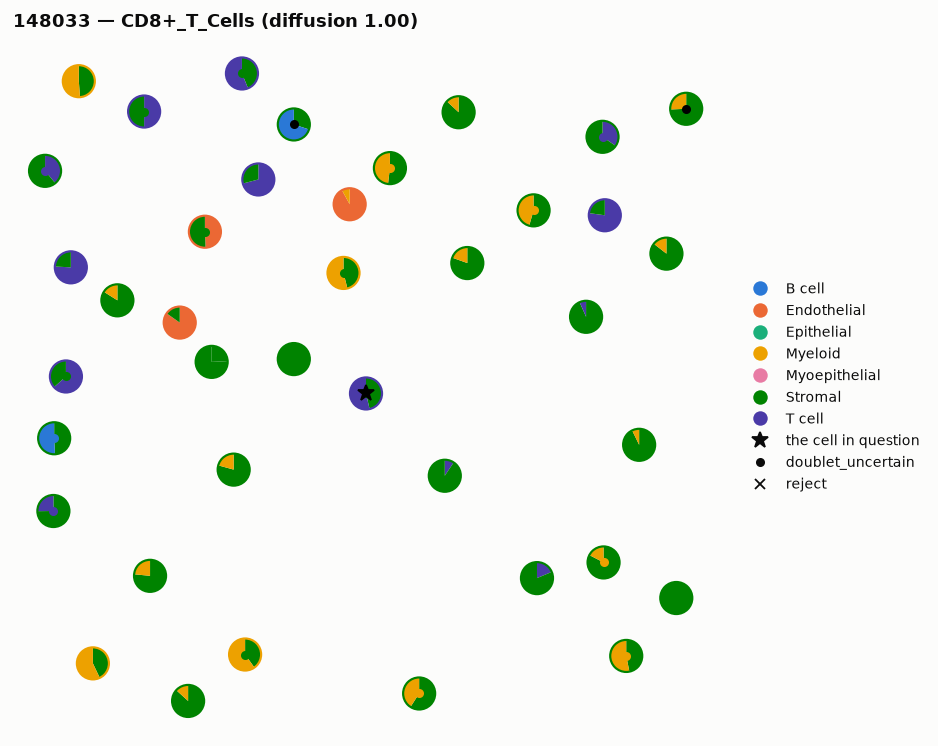

,148033
first_type,CD8+_T_Cells
second_type,Stromal
spot_class,doublet_certain
weight_first_type,0.536134
neighborhood_weights_second_type,1.0


In [23]:
pie_df = pysplit.pie_dataframe(rctd_result)

candidates = work.obs[
    (work.obs["neighborhood_weights_second_type"] > 0.2)
    & work.obs["first_type"].isin(["CD4+_T_Cells", "CD8+_T_Cells"])
    & (work.obs["spot_class"].astype(object) != "reject")
].sort_values("neighborhood_weights_second_type", ascending=False)

if len(candidates):
    focus = candidates.index[0]
    # cell type -> its class colour, so the pies use 7 hues rather than 17
    pie_palette = {t: CLASS_COLOR[c] for t, c in tut.CELL_TYPE_TO_CLASS.items()}
    # legend=False: pysplit would list all 17 cell types, and since several
    # share a class colour the rows would be indistinguishable. A class legend
    # is what the colours actually encode.
    ax = pysplit.plot_pie_around_cell(pie_df, cell_id=focus, radius=50,
                                      palette=pie_palette, legend=False)
    handles = [plt.Line2D([], [], marker="o", linestyle="", markersize=8,
                          markerfacecolor=CLASS_COLOR[c], markeredgecolor="none",
                          label=c) for c in CLASSES]
    handles += [
        plt.Line2D([], [], marker="*", linestyle="", color=INK, markersize=9,
                   label="the cell in question"),
        plt.Line2D([], [], marker="o", linestyle="", color=INK, markersize=4,
                   label="doublet_uncertain"),
        plt.Line2D([], [], marker="x", linestyle="", color=INK, markersize=5,
                   label="reject"),
    ]
    ax.legend(handles=handles, loc="center left", bbox_to_anchor=(1.02, 0.5),
              frameon=False, fontsize=8)
    ax.set_title(f"{focus} — {work.obs.loc[focus, 'first_type']}"
                 f" (diffusion {work.obs.loc[focus, 'neighborhood_weights_second_type']:.2f})",
                 loc="left", fontsize=10, color=INK)
    plt.show()
    display(work.obs.loc[[focus], ["first_type", "second_type", "spot_class",
                                   "weight_first_type",
                                   "neighborhood_weights_second_type"]].T)
else:
    print("No strongly contaminated T cell in this crop.")